# Klasifikasi Citra Bunga Menggunakan Multi-Layer Perceptron (MLP)

**Mata Kuliah:** Pengolahan Citra Digital (SIF202)
**Tahun Ajaran:** Genap 2025/2026
**Dosen Pengampu:** Teuku Rizky Noviandy, S.Kom., M.Kom.

**Nama Lengkap:** Reza Pahlefi
**NIM:** 24146013

## Deskripsi Proyek
Notebook ini membangun model klasifikasi citra bunga (5 kelas: *daisy, dandelion, rose, sunflower, tulip*) menggunakan algoritma **Multi-Layer Perceptron (MLP)** dari `scikit-learn`, dengan dataset **Flowers Recognition** dari Kaggle. Tahapan yang dilakukan meliputi: pemuatan data, praproses citra, ekstraksi fitur, pembagian data latih/uji, pelatihan model, evaluasi performa, dan visualisasi hasil prediksi.

## 1. Import Library

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# NIM digunakan sebagai random_state agar hasil dapat direproduksi
NIM = 24146013
np.random.seed(NIM)

## 2. Unduh Dataset dari Kaggle

Dataset dapat diunduh dari: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition

**Opsi A - Menggunakan Kaggle API (Google Colab / lokal dengan kaggle.json):**
```python
from google.colab import files
files.upload()  # unggah file kaggle.json Anda

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d alxmamaev/flowers-recognition
!unzip -q flowers-recognition.zip -d flowers_dataset
```

**Opsi B - Manual:** unduh langsung dari halaman Kaggle di atas, ekstrak, lalu sesuaikan variabel `DATASET_PATH` pada sel berikutnya dengan lokasi folder hasil ekstrak (folder yang berisi 5 subfolder: daisy, dandelion, rose, sunflower, tulip).

In [ ]:
# Sesuaikan path berikut dengan lokasi dataset pada environment Anda
DATASET_PATH = "archive/flowers"  # contoh path setelah ekstrak
IMG_SIZE = 64  # ukuran citra setelah di-resize (64x64 piksel)

## 3. Pemuatan dan Praproses Data

Setiap citra dibaca, dikonversi ke ruang warna RGB, kemudian di-*resize* menjadi ukuran seragam (64x64 piksel) agar dapat diproses oleh model. Label kelas diambil dari nama folder masing-masing kategori.

In [5]:
def load_dataset(dataset_path, img_size=64):
    categories = sorted([d for d in os.listdir(dataset_path)
                          if os.path.isdir(os.path.join(dataset_path, d))])
    images, labels = [], []
    for label in categories:
        folder = os.path.join(dataset_path, label)
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            img = cv2.imread(fpath)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

X_images, y_labels = load_dataset(DATASET_PATH, IMG_SIZE)
print("Total gambar:", len(X_images))
print("Ukuran tiap gambar:", X_images[0].shape)
print("Kelas ditemukan:", sorted(set(y_labels)))

Total gambar: 4317
Ukuran tiap gambar: (64, 64, 3)
Kelas ditemukan: [np.str_('daisy'), np.str_('dandelion'), np.str_('rose'), np.str_('sunflower'), np.str_('tulip')]


## 4. Encoding Label dan Ekstraksi Fitur

Label kategorikal (nama kelas) diubah menjadi bentuk numerik menggunakan `LabelEncoder`. Untuk ekstraksi fitur, setiap citra RGB berukuran 64x64x3 di-*flatten* menjadi vektor 1 dimensi dan dinormalisasi ke rentang [0, 1], karena MLP membutuhkan input berupa vektor fitur numerik.

In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
print("Mapping kelas:", dict(zip(le.classes_, range(len(le.classes_)))))

# Flatten + normalisasi
X_flat = X_images.reshape(X_images.shape[0], -1).astype("float32") / 255.0
print("Shape data fitur setelah flatten:", X_flat.shape)

Mapping kelas: {np.str_('daisy'): 0, np.str_('dandelion'): 1, np.str_('rose'): 2, np.str_('sunflower'): 3, np.str_('tulip'): 4}
Shape data fitur setelah flatten: (4317, 12288)


## 5. Pembagian Data Latih dan Data Uji

Data dibagi menjadi 80% data latih dan 20% data uji menggunakan `train_test_split`, dengan `random_state` diisi NIM agar hasil pembagian konsisten dan dapat direproduksi. Indeks data ikut disimpan agar citra asli (sebelum flatten) dapat ditelusuri kembali untuk keperluan visualisasi prediksi.

In [7]:
indices = np.arange(len(X_flat))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_flat,
    y_encoded,
    indices,
    test_size=0.2,
    random_state=NIM,
    stratify=y_encoded
)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji  :", X_test.shape[0])

Jumlah data latih: 3453
Jumlah data uji  : 864


## 6. Membangun dan Melatih Model MLP

Model klasifikasi dibangun menggunakan `MLPClassifier` dari scikit-learn dengan 2 hidden layer (256 dan 128 neuron), fungsi aktivasi ReLU, dan optimizer Adam.

In [8]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=NIM,
    verbose=True
)

mlp.fit(X_train, y_train)

Iteration 1, loss = 3.16687822
Iteration 2, loss = 1.46885097
Iteration 3, loss = 1.33069301
Iteration 4, loss = 1.28270376
Iteration 5, loss = 1.24618268
Iteration 6, loss = 1.29080808
Iteration 7, loss = 1.17747080
Iteration 8, loss = 1.16700101
Iteration 9, loss = 1.19882214
Iteration 10, loss = 1.11411941
Iteration 11, loss = 1.10063553
Iteration 12, loss = 1.07672238
Iteration 13, loss = 1.04311514
Iteration 14, loss = 1.00346589
Iteration 15, loss = 0.97588426
Iteration 16, loss = 0.97714293
Iteration 17, loss = 1.01435828
Iteration 18, loss = 0.93729651
Iteration 19, loss = 0.93560654
Iteration 20, loss = 0.91350096
Iteration 21, loss = 0.86080539
Iteration 22, loss = 0.87173343
Iteration 23, loss = 0.84499526
Iteration 24, loss = 0.82923418
Iteration 25, loss = 0.77555662
Iteration 26, loss = 0.74959904
Iteration 27, loss = 0.75654382
Iteration 28, loss = 0.70145220
Iteration 29, loss = 0.68841350
Iteration 30, loss = 0.72109872
Iteration 31, loss = 0.67426854
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",24146013
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5


## 7. Evaluasi Model

Model dievaluasi menggunakan `classification_report` yang menampilkan nilai *precision*, *recall*, *f1-score*, dan *accuracy* untuk masing-masing kelas.

In [9]:
y_pred = mlp.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

=== Classification Report ===
              precision    recall  f1-score   support

       daisy     0.4225    0.3922    0.4068       153
   dandelion     0.4859    0.5762    0.5272       210
        rose     0.4561    0.3312    0.3838       157
   sunflower     0.6455    0.4830    0.5525       147
       tulip     0.3815    0.4822    0.4260       197

    accuracy                         0.4618       864
   macro avg     0.4783    0.4530    0.4593       864
weighted avg     0.4726    0.4618    0.4611       864



### Confusion Matrix (opsional, untuk analisis tambahan)

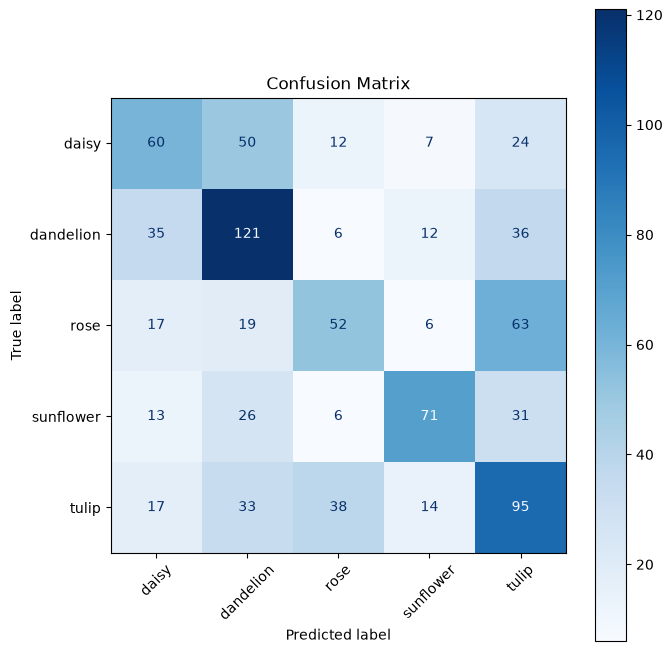

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 8. Visualisasi Hasil Prediksi

Diambil 5 gambar acak dari setiap kelas pada data uji (total 25 gambar), lalu ditampilkan label sebenarnya (*True*) dan label hasil prediksi (*Pred*). Judul berwarna **hijau** menandakan prediksi benar, dan **merah** menandakan prediksi salah.

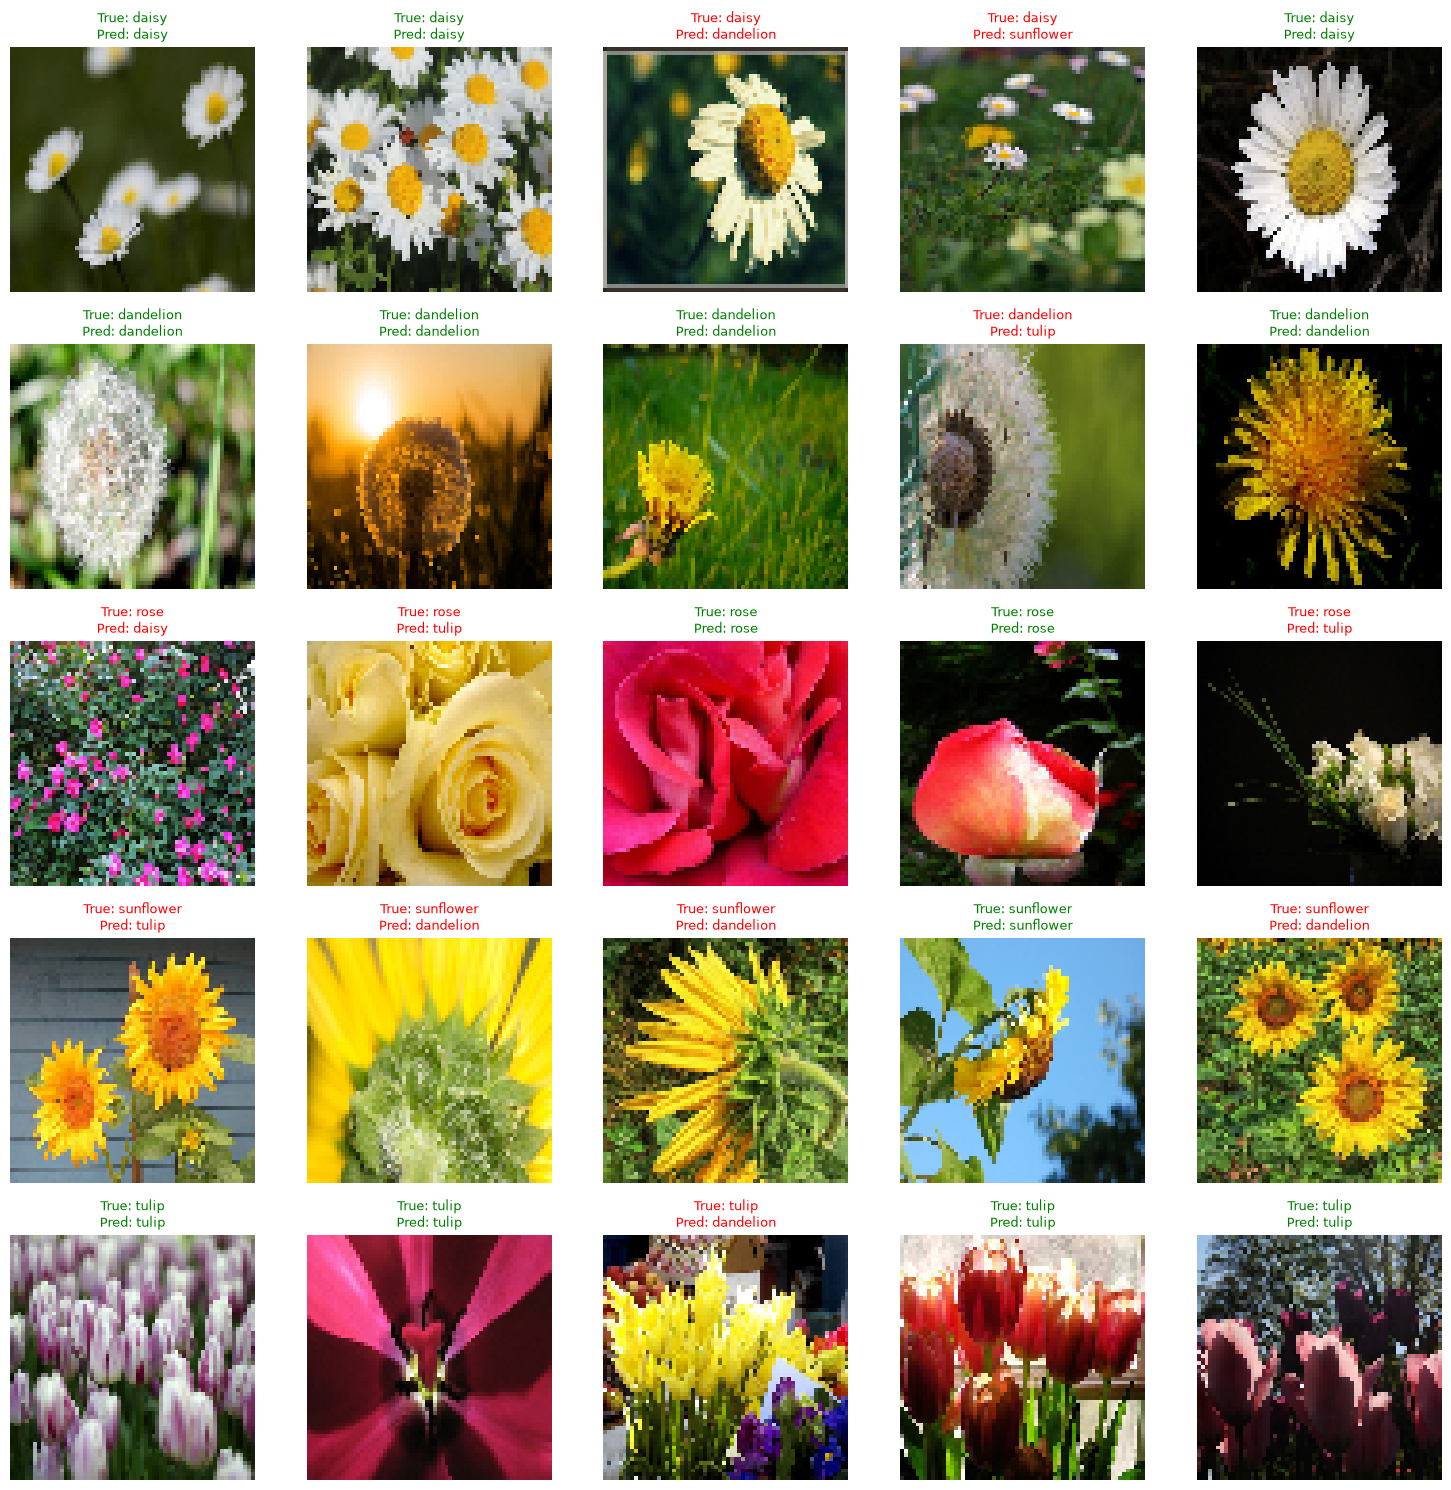

In [11]:
def show_predictions(idx_test, X_images, y_test, y_pred, le, n_per_class=5, seed=NIM):
    rng = np.random.default_rng(seed)
    classes = le.classes_
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(3 * n_per_class, 3 * len(classes)))

    for row, cls in enumerate(classes):
        cls_id = le.transform([cls])[0]
        cls_positions = np.where(y_test == cls_id)[0]
        chosen = rng.choice(cls_positions, size=min(n_per_class, len(cls_positions)), replace=False)

        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(chosen):
                pos = chosen[col]
                img_idx = idx_test[pos]
                img = X_images[img_idx]
                true_label = cls
                pred_label = le.inverse_transform([y_pred[pos]])[0]
                color = "green" if true_label == pred_label else "red"
                ax.imshow(img)
                ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
            ax.axis("off")

    plt.tight_layout()
    plt.savefig("hasil_prediksi.png", dpi=150)
    plt.show()

show_predictions(idx_test, X_images, y_test, y_pred, le)